# Problem
- We are predecting mobile fincial transaction is fraud("isFraud") or not using their 'step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest' and 'newbalanceDest'. This is The Classification Problem
- **Dataset:** Fraud_Analysis_Cleaned_Dataset.csv
- **Models:** Logistic Regression, Random Forests, Gradient Boosting, SVM, XGBoost

### Workflow
- Load pre-cleaned data
- split the data
- Data Preprocessing (using Pipeline)
- model building
- HyperParameter tuning
- Model training
- Model compraision
- Classification Report & Confusion Matrix analyze
- Financial impact analysis
- Key insights
- Save best model(joblib)

In [1]:
#imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

In [2]:
#load Data
data = pd.read_csv(r"D:\ML_Project\fraud_detection_analysis\data\Fraud_Analysis_Cleaned_Dataset.csv")
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [3]:
df = data.copy()

In [4]:
df.shape

(11142, 10)

In [5]:
print("Unique nameOrig:", df["nameOrig"].nunique())
print("Unique nameDest:", df["nameDest"].nunique())

Unique nameOrig: 11142
Unique nameDest: 7508


In [6]:
df.value_counts().sum()

np.int64(11142)

### Split the data

In [7]:
#train-test-split
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42, stratify=y)

### Feature Engineering

- **nameOrig** and **nameDest** are essentially identifiers rather than ordinary categorical features. Since all **nameOrig** values are unique and most **nameDest** values are also unique when applying One-Hot Encoding would create a **sparse** and **high-dimensional** matrix with little generalizable information. Therefore, we decided to drop both features from the dataset now.

In [8]:
def apply_feature_engineering(df_input):
    df_local = df_input.copy()

    # Drop high-cardinality identifier features
    cols_to_drop = [col for col in ["nameOrig", "nameDest"] if col in df_local.columns]
    df_local = df_local.drop(columns = cols_to_drop)

    # create useful feature
    df_local['is_all_funds_withdrawn'] = (df_local['oldbalanceOrg'] == df_local['amount']).astype(int)
    df_local["is_dest_empty_before"] = (df_local["oldbalanceDest"] == 0).astype(int)
    
    df_local["amount_to_balance_ratio"] = df_local["amount"] / (df_local["oldbalanceOrg"] + 1)

    return df_local

In [9]:
# Apply feature engineering to train and test data separately

X_train = apply_feature_engineering(X_train)

X_test = apply_feature_engineering(X_test)

In [10]:
X_train

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,is_all_funds_withdrawn,is_dest_empty_before,amount_to_balance_ratio
10340,7,PAYMENT,13367.64,41666.00,28298.36,0.00,0.00,0,1,0.320821
9605,7,CASH_OUT,307111.99,0.00,0.00,12900000.00,13100000.00,0,0,307111.990000
6697,6,PAYMENT,5435.22,0.00,0.00,0.00,0.00,0,1,5435.220000
3437,1,PAYMENT,186.22,124804.72,124618.50,0.00,0.00,0,1,0.001492
5526,4,PAYMENT,4104.55,5865.00,1760.45,0.00,0.00,0,1,0.699719
...,...,...,...,...,...,...,...,...,...,...
4832,2,PAYMENT,956.17,759914.47,758958.30,0.00,0.00,0,1,0.001258
1834,1,CASH_OUT,60758.42,0.00,0.00,155911.68,500631.71,0,0,60758.420000
7915,6,PAYMENT,8921.69,9260.00,338.31,0.00,0.00,0,1,0.963361
8945,7,TRANSFER,77911.42,73140.00,0.00,93689.50,8748005.25,0,0,1.065222


In [11]:
# Identify Categorical and numerical features
cat_features = X_train.select_dtypes(include="object").columns.to_list()
num_features = X_train.select_dtypes(include="number").columns.to_list()

print("Categorical Features:\n", cat_features)
print("\nNumerical Features:\n", num_features)

Categorical Features:
 ['type']

Numerical Features:
 ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'is_all_funds_withdrawn', 'is_dest_empty_before', 'amount_to_balance_ratio']


### Data Pre-processing(using pipeline)

In [12]:
# numeric pipeline
num_pipeline = Pipeline(steps = [
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline(steps = [
    ("ohe", OneHotEncoder(handle_unknown = "ignore"))
])

# Combine pipeline
preprocessor = ColumnTransformer(transformers = [
    ("numeric", num_pipeline, num_features),
    ("categorical", cat_pipeline, cat_features)
])

### Define model

In [13]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(n_estimators = 200,
        class_weight = "balanced",
        random_state = 42,
        n_jobs = -1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state = 42
    ),

    "SVM": SVC(
        probability = True,
        class_weight = "balanced",
        random_state = 42
    ),

    "XGBoost": XGBClassifier(
        eval_metric = "logloss",
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
        random_state = 42
    )
}

#### Define Hyperparameters

In [14]:
param_grid = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1],
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 2],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 5],
    },
    "SVM": {
        "model__C": [1, 10],
        "model__kernel": ["linear", "rbf"],
    },
    "XGBoost": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.01, 0.1],
    },
}

#### Model Training & Hyperparameter Tuning

In [15]:
# Hyperparameter Tuning

results = []
best_models = {}

for model_name, model in models.items():

    print(f"Model Training: {model_name}")

    # Complete pipeline for preprocessing and model training
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Perform hyperparameter tuning using GridSearchCV
    grid_search = GridSearchCV(
        estimator = pipe,
        param_grid = param_grid[model_name],
        cv = 5,
        scoring = "f1",
        n_jobs = -1
    )

    # Fit the grid search on the training data
    grid_search.fit(X_train, y_train)

    # Save the best-performing pipeline 
    best_models[model_name] = grid_search.best_estimator_

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Prediction probability
    y_prob = grid_search.predict_proba(X_test)[:, 1]

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy":metrics.accuracy_score(y_test, y_pred),
        "Precision": metrics.precision_score(y_test, y_pred),
        "Recall": metrics.recall_score(y_test, y_pred),
        "F1 Score": metrics.f1_score(y_test, y_pred),
        "ROC-AUC": metrics.roc_auc_score(y_test, y_prob)
    })

Model Training: Logistic Regression
Model Training: Random Forest
Model Training: Gradient Boosting
Model Training: SVM
Model Training: XGBoost


#### Model Comparison

In [29]:
result_df = pd.DataFrame(results)

# Sort the result dataframe by F1 Score (best model first)
result_df = result_df.round(4).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
result_df.to_csv(r"D:\ML_Project\fraud_detection_analysis\data\result_df.csv")

print("\nModel Comparison:\n", result_df)

# Select the best model from the sorted result dataframe
best_model_name = result_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("\nBest Model:", best_model_name)



Model Comparison:
                  Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0        Random Forest    0.9996        1.0  0.9956    0.9978   1.0000
1                  SVM    0.9996        1.0  0.9956    0.9978   0.9958
2    Gradient Boosting    0.9996        1.0  0.9956    0.9978   0.9978
3              XGBoost    0.9996        1.0  0.9956    0.9978   1.0000
4  Logistic Regression    0.9991        1.0  0.9912    0.9956   0.9971

Best Model: Random Forest


In [17]:
y_pred_best = best_model.predict(X_test)

### Classification Report & Confusion Matrix

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       228

    accuracy                           1.00      2229
   macro avg       1.00      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229



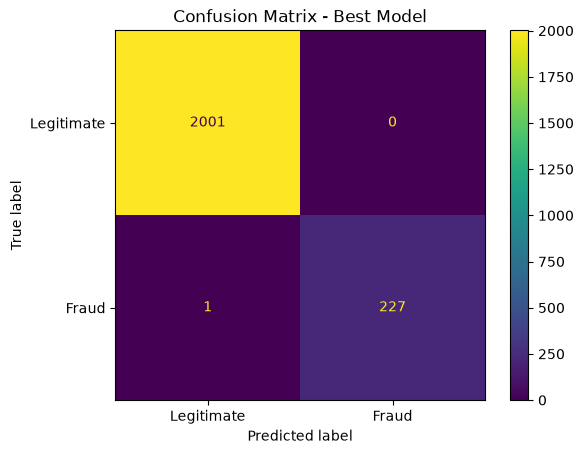

In [19]:
# Classification Report
print(
    metrics.classification_report(
        y_test,
        y_pred_best
    )
)

# Confusion Matrix for Best Model
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["Legitimate", "Fraud"],
)

plt.title("Confusion Matrix - Best Model")
plt.show()

#### Financial Impact Analysis

In [20]:
# Create a DataFrame from test data for Financial Impact Analysis and add actual and predicted labels
financial_analysis_df = X_test.copy()

financial_analysis_df["actual_fraud"] = y_test
financial_analysis_df["predicted_fraud"] = y_pred_best

financial_analysis_df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,is_all_funds_withdrawn,is_dest_empty_before,amount_to_balance_ratio,actual_fraud,predicted_fraud
4522,2,PAYMENT,23147.49,169352.26,146204.77,0.00,0.00,0,1,0.136682,0,0
7816,6,PAYMENT,17978.87,31239.00,13260.13,0.00,0.00,0,1,0.575508,0,0
1494,1,TRANSFER,100677.86,0.00,0.00,701567.56,55974.56,0,0,100677.860000,0,0
1713,1,PAYMENT,2056.59,0.00,0.00,0.00,0.00,0,1,2056.590000,0,0
1506,1,TRANSFER,161217.61,0.00,0.00,199733.00,5602234.95,0,0,161217.610000,0,0


In [21]:
# Business assumptions

TRANSACTION_FEE_RATE = 0.02  # Assumption: 2% fee on successfully processed legitimate transactions
COST_PER_FALSE_POSITIVE = 1500  # Assumption: estimated cost of wrongly blocking one legitimate transaction

In [22]:
# Legitimate(non-fraudulent) transactions successfully processed (True Negatives)

legitimate_processed_amount = financial_analysis_df.loc[
    (financial_analysis_df["actual_fraud"] == 0) &
    (financial_analysis_df["predicted_fraud"] == 0),
    "amount"
].sum()

# Total actual fraud amount in the test set

total_actual_fraud_amount = financial_analysis_df.loc[
    financial_analysis_df["actual_fraud"] == 1,
    "amount"
].sum()

# Expected revenue from successfully processed legitimate transactions

expected_revenue = legitimate_processed_amount * TRANSACTION_FEE_RATE

# Fraud that was not detected (False Negatives)

missed_fraud_amount = financial_analysis_df.loc[
    (financial_analysis_df["actual_fraud"] == 1) &
    (financial_analysis_df["predicted_fraud"] == 0),
    "amount"
].sum()

# Fraud correctly detected (True Positives)

detected_fraud_amount = financial_analysis_df.loc[
    (financial_analysis_df["actual_fraud"] == 1) &
    (financial_analysis_df["predicted_fraud"] == 1),
    "amount"
].sum()

# Legitimate transactions wrongly flagged as fraud (False Positives)

false_positive_count = (
    (financial_analysis_df["actual_fraud"] == 0) &
    (financial_analysis_df["predicted_fraud"] == 1)
).sum()

# Estimated cost of false positives

false_positive_cost = false_positive_count * COST_PER_FALSE_POSITIVE

# Total estimated financial losses

total_estimated_losses = missed_fraud_amount + false_positive_cost

# Estimated net financial impact

estimated_net_financial_impact = (
    expected_revenue - total_estimated_losses
)


# Create Financial Impact Analysis DataFrame
financial_impact_analysis_df = pd.DataFrame({
    "Financial Metrics": [
        "Legitimate Transaction Amount",
        "Total Actual Fraud Amount",
        "Fraud Detected by Model (TP)",
        "Expected Revenue ",
        "Missed Fraud Loss (FN)",
        "False Positive Cost (FP)",
        "Total Estimated Losses",
        "Estimated Net Profit"
    ],

    "Amount": [
        legitimate_processed_amount,
        total_actual_fraud_amount,
        detected_fraud_amount,
        expected_revenue,
        missed_fraud_amount,
        false_positive_cost,
        total_estimated_losses,
        estimated_net_financial_impact
    ]
})

In [23]:
financial_impact_analysis_df.style.format({
    "Amount": "{:.2f}"
})

,Financial Metrics,Amount
0,Legitimate Transaction Amount,205491066.96
1,Total Actual Fraud Amount,235846526.37
2,Fraud Detected by Model (TP),235430525.04
3,Expected Revenue,4109821.34
4,Missed Fraud Loss (FN),416001.33
5,False Positive Cost (FP),0.00
6,Total Estimated Losses,416001.33
7,Estimated Net Profit,3693820.01


### Visualization

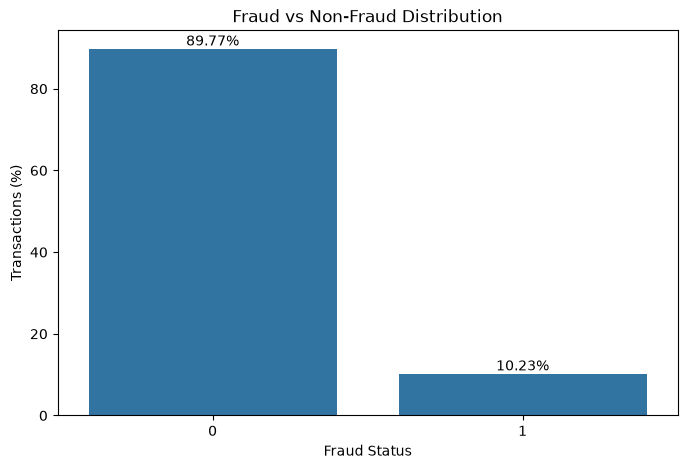

In [24]:
# Fraud vs non-Fraud distribution
fraud_percentage = (
    financial_analysis_df["actual_fraud"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=fraud_percentage.index,
    y=fraud_percentage.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Fraud Status")
plt.ylabel("Transactions (%)")
plt.show()

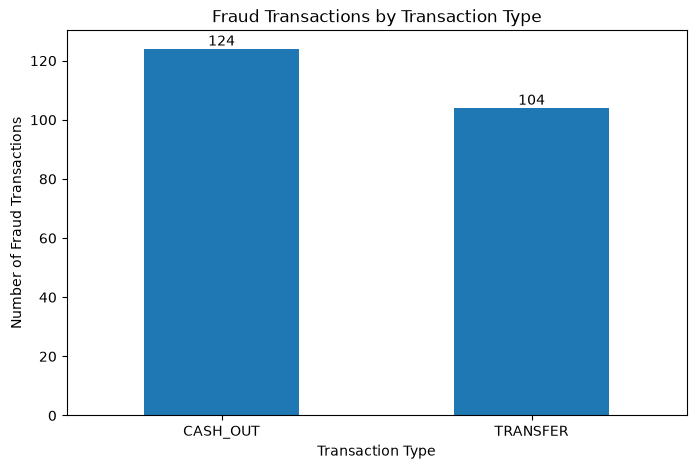

In [25]:
# Fraud cases by transaction type
fraud_by_type = (
    financial_analysis_df[financial_analysis_df["actual_fraud"] == 1]
    .groupby("type")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = fraud_by_type.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container)
    
plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.xticks(rotation=0)
plt.ylabel("Number of Fraud Transactions")
plt.show()

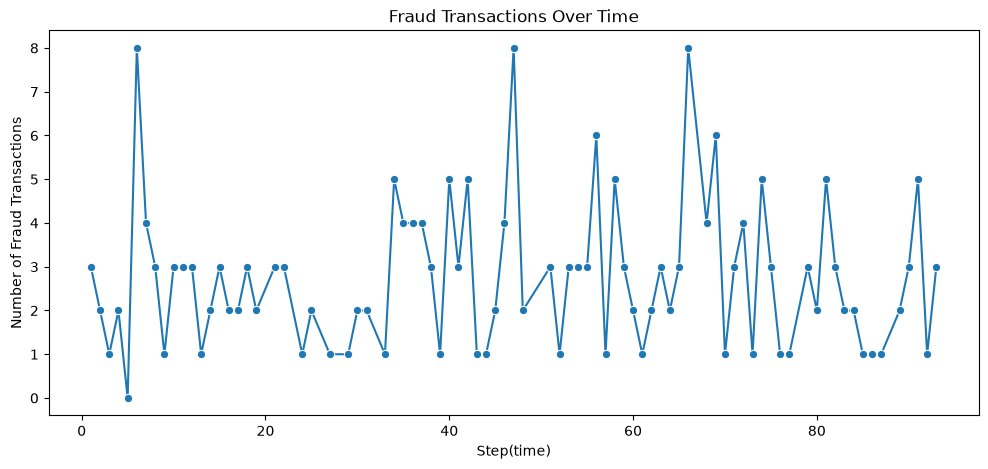

In [26]:
# Fraud cases over transaction steps

fraud_by_step = (
    financial_analysis_df
    .groupby("step")["actual_fraud"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=fraud_by_step,
    x="step",
    y="actual_fraud",
    marker="o"
)

plt.title("Fraud Transactions Over Time")
plt.xlabel("Step(time)")
plt.ylabel("Number of Fraud Transactions")

plt.show()

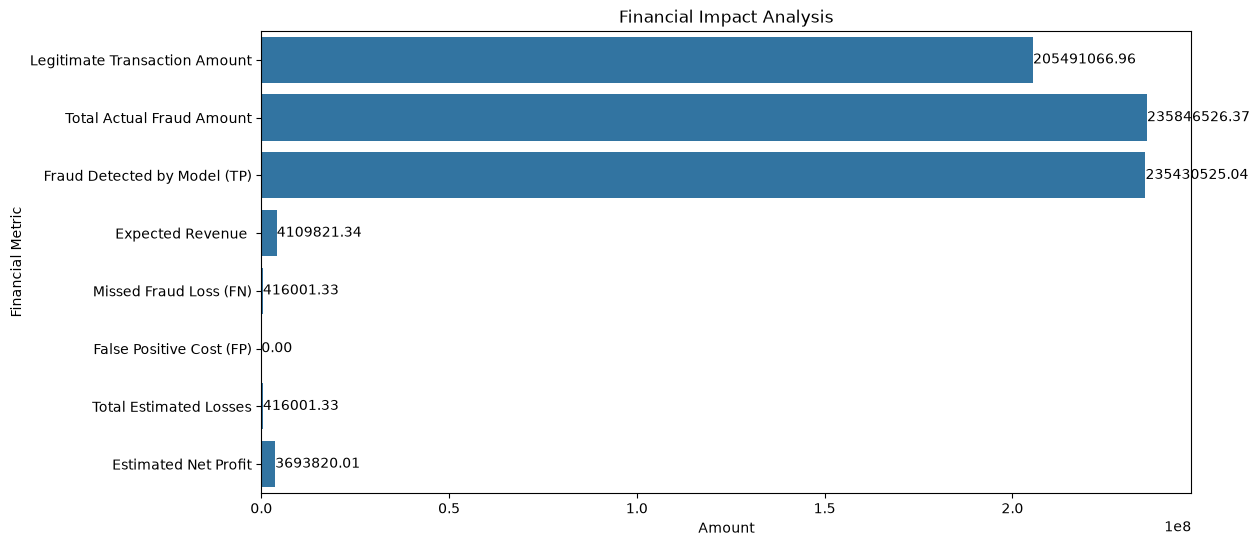

In [27]:
# Financial Impact Analysis

plt.figure(figsize = (12,6))

ax = sns.barplot(
    data=financial_impact_analysis_df,
    x="Amount",
    y="Financial Metrics"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title("Financial Impact Analysis", )
plt.xlabel("Amount")
plt.ylabel("Financial Metric")

plt.show()

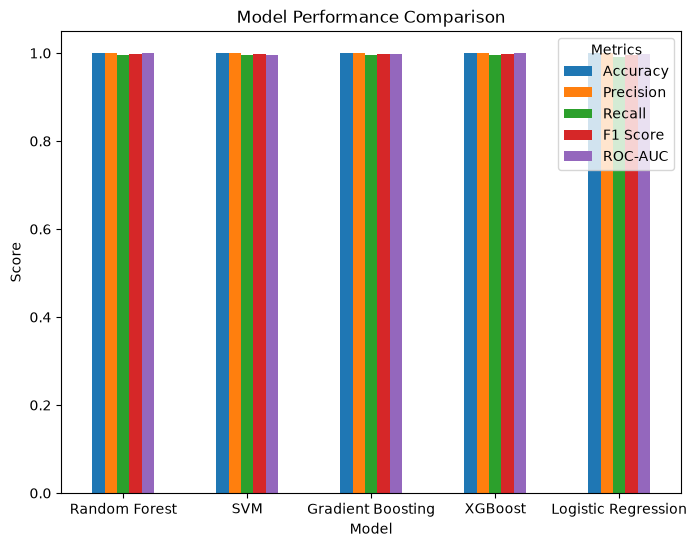

In [28]:
# Model Performance Comparison

performance_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

result_df.set_index("Model")[performance_metrics].plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation = 0)
plt.legend(title="Metrics")

plt.show()

In [31]:
import joblib

In [32]:
best_model_path = r"D:\ML_Project\fraud_detection_analysis\best_model.pkl"
joblib.dump(best_model, best_model_path)

print(f"\nBest model saved successfully to: {best_model_path}")


Best model saved successfully to: D:\ML_Project\fraud_detection_analysis\best_model.pkl
